In [1]:
import os
import cv2
import numpy as np
from skimage.feature import hog

DATASET_PATH = "dataset"

X = []
y = []

IMG_SIZE = (128, 128)

for label in ["organic", "inorganic"]:

    folder = os.path.join(DATASET_PATH, label)

    for file in os.listdir(folder):

        path = os.path.join(folder, file)

        img = cv2.imread(path)

        if img is None:
            continue

        img = cv2.resize(img, IMG_SIZE)

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        features = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2),
            block_norm='L2-Hys'
        )

        X.append(features)
        y.append(label)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(300, 8100)
(300,)


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
from sklearn.svm import SVC

model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [5]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

pred = model.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

print(classification_report(
    y_test,
    pred
))

Accuracy: 0.8833333333333333
              precision    recall  f1-score   support

   inorganic       1.00      0.77      0.87        30
     organic       0.81      1.00      0.90        30

    accuracy                           0.88        60
   macro avg       0.91      0.88      0.88        60
weighted avg       0.91      0.88      0.88        60



In [6]:
import joblib

joblib.dump(model, "waste_classifier.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

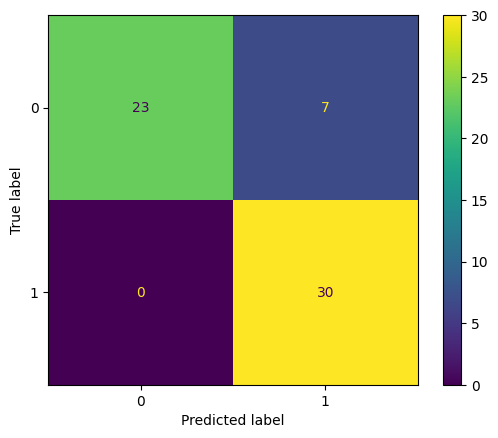

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt

pred = model.predict(X_test)

cm = confusion_matrix(y_test, pred)

ConfusionMatrixDisplay(cm).plot()
plt.show()

In [10]:
import cv2
import joblib
from skimage.feature import hog

model = joblib.load("waste_classifier.pkl")
scaler = joblib.load("scaler.pkl")

IMG_SIZE = (128, 128)

def predict_image(image_path):

    img = cv2.imread(image_path)

    img = cv2.resize(img, IMG_SIZE)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    feature = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm='L2-Hys'
    )

    feature = scaler.transform([feature])

    prediction = model.predict(feature)[0]

    return prediction

print(
    predict_image("R_984.jpg")
)

inorganic
